# Group 24 — Bicycle lane quality
## Data preparation pipeline

Group members and student numbers:

- Lars Heijnen — 2233878
- Amir — xx
- Brian — xx

In this notebook, we prepare our cycling recordings for model training and testing. We first check
the raw data and select the intervals used for analysis. We then align the sensor signals, divide
them into windows, and extract features. Training, evaluation, and deployment will be added later.

The sections follow the order in which the data is processed. All project code is included here;
we do not import our own Python scripts. To reproduce the results, select the assignment's `.venv`
as the kernel, restart it, and run all cells from top to bottom.

We follow sections 3–4 of `report_files/Assignment12026.pdf` and the preprocessing examples in
`Preprocessing_Canvas/instruction_3.ipynb`. The analysis uses the Python standard library,
NumPy, pandas, Matplotlib, and scikit-learn, which are used in the practical.

## 1. Objective and collection setup
Our aim is to classify short periods of cycling as **smooth** or **bumpy** using sensor measurements.
Rider IDs, road names, file paths, and timestamps help us track the data, but are not model features.

Each recording covers a different road segment, with no repeated passes. We placed the phone in a
tight right trouser pocket and aimed to keep speed and gear consistent where applicable. Some routes
required small turns, but there were no stops during the cycling section. Speed and placement describe
our collection procedure; they were not independently measured.

The beginning and end contain stationary periods and phone handling. For this baseline, we retain these periods
along with the cycling data. Handling windows therefore receive the recording's surface label even
though they do not directly measure road quality. We document this as a limitation. Large peaks alone cannot identify handling, since bumps also cause
large accelerations. Brian has not yet collected bumpy recordings, which limits comparisons across riders.

Recordings have different lengths. Fixed-duration windows give the model a consistent input size,
although longer recordings still contribute more windows. We keep the raw files unchanged.

### 1.1 Imports and package versions
The table below records the Python and package versions used for this run.

In [1]:
from pathlib import Path
import sys
import re
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

versions = {"Python": sys.version.split()[0], "numpy": np.__version__,
            "pandas": pd.__version__, "matplotlib": matplotlib.__version__,
            "scikit-learn": sklearn.__version__}
display(pd.Series(versions, name="version").to_frame())
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.2})

,version
Python,3.12.14
numpy,2.5.2
pandas,3.0.5
matplotlib,3.11.1
scikit-learn,1.9.0


### 1.2 Paths and initial settings
The paths work from either the assignment directory or its parent. We leave `DeploymentData` out of
this stage because the assignment reserves it for applying the final model.

We start with two-second windows without overlap and a common sampling grid of 100 Hz. We interpolate
across gaps of at most 0.05 seconds and reject windows containing longer gaps. These are initial choices
that we will justify and assess using development data. We do not apply smoothing yet, since it could
remove vibrations that help distinguish road surfaces.

In [2]:
ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "recordings" / "raw").is_dir():
    ROOT = ROOT / "Assignment 1"
RAW_DIR = ROOT / "data" / "recordings" / "raw"
assert RAW_DIR.is_dir(), "Run from the assignment folder or its parent."
SENSORS = {"Accelerometer": "acc", "Gyroscope": "gyro", "Gravity": "gravity"}
AXES = ["x", "y", "z"]  # Select by name: CSV storage order is z, y, x.
SEED = 24
TEST_FRACTION = 0.25
SAMPLE_RATE_HZ = 100
WINDOW_SECONDS = 2.0
MAX_GAP_SECONDS = 0.05
LABEL_MAP = {"smooth": 0, "bumpy": 1}
# Stable anonymous display IDs; raw paths remain local and are not modeling features.
PARTICIPANTS = {"lars": "P01", "brian": "P02"}
assert SAMPLE_RATE_HZ == 100, "Changing the target rate requires reviewing resampling and anti-alias filtering."
assert np.isfinite(WINDOW_SECONDS) and WINDOW_SECONDS > 0
assert np.isclose(WINDOW_SECONDS * SAMPLE_RATE_HZ, round(WINDOW_SECONDS * SAMPLE_RATE_HZ))
assert np.isfinite(MAX_GAP_SECONDS) and MAX_GAP_SECONDS > 0
assert 0 < TEST_FRACTION < 1


## 2. Recording inventory
We build a table with one row per recording. We use the format
`participant_surface_location/run`, such as `P01_bumpy_cb_2` or `P02_smooth_tu_e_south_1`.
The location/run part comes from the folder name, with repeated participant names and surface labels
removed. These readable IDs connect the inventory, plots, windows, and data splits. We check that
all IDs are unique. New participants need an explicit code in `PARTICIPANTS`.
Since every recording represents a different road segment, its recording ID also identifies its road
group. If we later add repeated passes, we must revise the grouping and split procedure first.

We also calculate file hashes to detect identical sensor exports. This prevents the same data from
appearing on both sides of a split. The tables use participant codes, but the source folders and
metadata still need to be anonymized before submission.

In [3]:
records = []
for folder in sorted(RAW_DIR.glob("*/*/*")):
    if not folder.is_dir():
        continue
    surface, participant, recording_name = folder.relative_to(RAW_DIR).parts
    if surface not in LABEL_MAP:
        raise ValueError(f"Unknown surface folder: {surface}")
    if participant not in PARTICIPANTS:
        raise ValueError(f"Add a participant code to PARTICIPANTS for: {participant}")
    participant_id = PARTICIPANTS[participant]
    # Remove repeated label/name tokens while preserving the location and run name.
    tokens = re.findall(r"[a-z0-9]+", recording_name.lower())
    redundant_tokens = set(LABEL_MAP) | set(re.findall(r"[a-z0-9]+", participant.lower()))
    recording_slug = "_".join(token for token in tokens if token not in redundant_tokens)
    if not recording_slug:
        raise ValueError(f"Recording folder needs a descriptive location/run name: {recording_name}")
    recording_id = f"{participant_id}_{surface}_{recording_slug}"
    records.append({"recording_id": recording_id, "road_group": recording_id,
                    "participant_id": participant_id, "surface": surface, "folder": folder})
manifest = pd.DataFrame(records)
assert not manifest.empty, "No recording folders discovered."
assert manifest.recording_id.is_unique, "Descriptive IDs collide; give the source recordings distinct location/run names."
manifest = manifest.set_index("recording_id", drop=False)
display(pd.crosstab(manifest.participant_id, manifest.surface))
print(f"Discovered {len(manifest)} recordings. P01 = Lars; P02 = Brian (local working mapping).")

surface,bumpy,smooth
participant_id,,
P01,9,7
P02,0,12


Discovered 28 recordings. P01 = Lars; P02 = Brian (local working mapping).


## 3. Check the raw sensor data
For each calibrated sensor stream, we check the required columns, numeric values, timestamp order,
duration, and sampling rate. We flag missing or invalid data instead of silently correcting it.
Recordings with a failed check cannot be included until the issue is resolved.

The timestamps are stored as integer nanoseconds. We subtract a shared recording origin before
converting them to seconds, which avoids losing precision when aligning the sensors. We also check
that elapsed time is consistent with these timestamps.

We treat calibrated acceleration as linear acceleration in m/s², gyroscope values as rad/s, and
gravity as m/s², following the export convention used here. We therefore do not subtract gravity from
acceleration again. This assumption should be checked if devices or export settings change.
The uncalibrated exports are not used in this baseline.

The sampling-rate check supports recordings near the expected 100 Hz. Recordings that require
substantial downsampling need an anti-alias filter, which is not implemented in this baseline.

In [4]:
streams = {}
quality_rows = []
for recording_id, record in manifest.iterrows():
    for sensor in SENSORS:
        file = record.folder / f"{sensor}.csv"
        result = {"recording_id": recording_id, "sensor": sensor, "ok": False, "reason": ""}
        try:
            frame = pd.read_csv(file)
            required = ["time", "seconds_elapsed"] + AXES
            if not set(required).issubset(frame.columns):
                raise ValueError("Missing required columns")
            if len(frame) < 2:
                raise ValueError("Fewer than two samples")
            if not all(pd.api.types.is_numeric_dtype(frame[c]) for c in required):
                raise ValueError("Non-numeric measurements")
            if not np.isfinite(frame[required].to_numpy()).all():
                raise ValueError("Missing or non-finite measurements")
            if not pd.api.types.is_integer_dtype(frame.time):
                raise ValueError("Expected integer nanosecond timestamps")
            dt = np.diff(frame.time.to_numpy(dtype=np.int64)) / 1e9
            if (dt <= 0).any():
                raise ValueError("Duplicate or decreasing timestamps")
            if (np.diff(frame.seconds_elapsed) <= 0).any():
                raise ValueError("Non-increasing elapsed time")
            elapsed = frame.seconds_elapsed.to_numpy() - frame.seconds_elapsed.iloc[0]
            timestamp_elapsed = (frame.time.to_numpy(dtype=np.int64) - int(frame.time.iloc[0])) / 1e9
            if not np.allclose(elapsed, timestamp_elapsed, rtol=0, atol=0.001):
                raise ValueError("Elapsed time and timestamps disagree by more than 1 ms")
            rate = 1 / np.median(dt)
            # This baseline does not implement anti-alias filtering for substantial downsampling.
            if not 90 <= rate <= 105:
                raise ValueError("Sampling rate outside supported 90–105 Hz; review resampling")
            result.update(ok=True, rows=len(frame), duration_s=float((frame.time.iloc[-1] - frame.time.iloc[0]) / 1e9),
                          rate_hz=rate, large_gaps=int((dt > MAX_GAP_SECONDS).sum()),
                          sha256=hashlib.sha256(file.read_bytes()).hexdigest())
            streams[(recording_id, sensor)] = frame
        except (OSError, ValueError, pd.errors.ParserError) as error:
            result["reason"] = str(error)
        quality_rows.append(result)
quality = pd.DataFrame(quality_rows).reindex(columns=["recording_id", "sensor", "ok", "reason", "rows", "duration_s", "rate_hz", "large_gaps", "sha256"])
valid_ids = quality.groupby("recording_id").ok.all()
manifest["quality_ok"] = manifest.recording_id.map(valid_ids)
valid_hashes = quality.loc[quality.ok]
duplicate_exports = valid_hashes[valid_hashes.duplicated(["sensor", "sha256"], keep=False)]
if not duplicate_exports.empty:
    raise ValueError("Identical sensor exports found: investigate source duplication before splitting.")
display(quality.groupby("sensor").agg(recordings=("ok", "size"), passed=("ok", "sum"),
                                      min_hz=("rate_hz", "min"), max_hz=("rate_hz", "max")))
display(quality.loc[~quality.ok, ["recording_id", "sensor", "reason"]])

,recordings,passed,min_hz,max_hz
sensor,,,,
Accelerometer,28,28,99.581757,99.940036
Gravity,28,28,99.581757,99.940036
Gyroscope,28,28,99.581757,99.940036


,recording_id,sensor,reason


### 3.1 Sensor alignment and shared duration
We use the earliest calibrated timestamp as time zero. All trim boundaries and review plots refer to
this time axis. We check whether the sensor timestamps match exactly and calculate the interval covered
by all three sensors. A recording needs at least one window of shared coverage to continue.

In [5]:
origins = {}
manifest["common_start_s"] = np.nan
manifest["common_end_s"] = np.nan
manifest["exact_alignment"] = False
for recording_id in manifest.index[manifest.quality_ok]:
    frames = [streams[(recording_id, sensor)] for sensor in SENSORS]
    origin = min(int(frame.time.iloc[0]) for frame in frames)
    origins[recording_id] = origin
    starts = [(int(frame.time.iloc[0]) - origin) / 1e9 for frame in frames]
    ends = [(int(frame.time.iloc[-1]) - origin) / 1e9 for frame in frames]
    manifest.loc[recording_id, "common_start_s"] = max(starts)
    manifest.loc[recording_id, "common_end_s"] = min(ends)
    manifest.loc[recording_id, "exact_alignment"] = all(frames[0].time.equals(frame.time) for frame in frames[1:])
manifest["common_duration_s"] = manifest.common_end_s - manifest.common_start_s
manifest["coverage_ok"] = manifest.common_duration_s.ge(WINDOW_SECONDS)
manifest["quality_ok"] = manifest.quality_ok & manifest.coverage_ok
if (~manifest.coverage_ok).any():
    print("Insufficient shared coverage:", manifest.index[~manifest.coverage_ok].tolist())
print("Exactly aligned recordings:", int(manifest.exact_alignment.fillna(False).sum()))
display(manifest[["recording_id", "participant_id", "surface", "quality_ok", "common_duration_s", "exact_alignment"]].round(3))

Exactly aligned recordings: 27


,recording_id,participant_id,surface,quality_ok,common_duration_s,exact_alignment
recording_id,,,,,,
P01_bumpy_cb_2,P01_bumpy_cb_2,P01,bumpy,True,41.720,True
P01_bumpy_cb_3,P01_bumpy_cb_3,P01,bumpy,True,42.698,True
P01_bumpy_cb_4,P01_bumpy_cb_4,P01,bumpy,True,51.003,True
P01_bumpy_cb_5,P01_bumpy_cb_5,P01,bumpy,True,38.566,True
P01_bumpy_cb_6,P01_bumpy_cb_6,P01,bumpy,True,42.698,True
P01_bumpy_cb_7,P01_bumpy_cb_7,P01,bumpy,True,56.126,True
P01_bumpy_cb,P01_bumpy_cb,P01,bumpy,True,45.860,True
P01_bumpy_onder_de_brug_1,P01_bumpy_onder_de_brug_1,P01,bumpy,True,37.516,True
P01_bumpy_stratumsedijk,P01_bumpy_stratumsedijk,P01,bumpy,True,44.772,True


## 4. Split recordings into development and test sets
We reserve 25% of the recordings for final testing, while keeping both surface classes in each set.
All windows from a recording stay together. This lets us evaluate new recorded roads, but does not
test performance on new riders.

The random seed makes the split reproducible for the same input inventory. Adding recordings or
changing which recordings pass the quality checks can change the split. The fingerprint below
identifies the assignment of recordings in this run. Excluding a recording during review does not
reassign the remaining recordings. We will freeze the split before model development.

We can inspect test recordings to check recording quality and mark cycling boundaries. However, we
must not use their feature patterns or model scores to choose filters, features, or model settings.
Cross-validation will use only the development set.

In [6]:
candidates = manifest.loc[manifest.quality_ok]
assert candidates.road_group.is_unique, "Repeated roads require a group-aware outer split before proceeding."
split_map = {}
if candidates.surface.nunique() == 2 and candidates.surface.value_counts().min() >= 2 and len(candidates) >= 8:
    test_count = int(np.ceil(len(candidates) * TEST_FRACTION))
    if min(test_count, len(candidates) - test_count) < 2:
        raise ValueError("Split fraction must leave at least two recordings on each side.")
    development_ids, test_ids = train_test_split(candidates.recording_id.to_numpy(),
        test_size=TEST_FRACTION, stratify=candidates.surface, random_state=SEED)
    split_map.update({recording_id: "development" for recording_id in development_ids})
    split_map.update({recording_id: "test" for recording_id in test_ids})
manifest["split"] = manifest.recording_id.map(split_map).fillna("unassigned")
split_signature = hashlib.sha256(json.dumps(split_map, sort_keys=True).encode()).hexdigest()[:16]
print("Split fingerprint:", split_signature)
display(pd.crosstab([manifest.split, manifest.participant_id], manifest.surface))

Split fingerprint: dc509e0996a65fa4


surface                     bumpy  smooth
split       participant_id               
development P01                 7       5
            P02                 0       9
test        P01                 2       2
            P02                 0       3

## 5. Select recording intervals (optional trimming)
For our baseline, we use the full interval covered by all three sensors, including starting and
ending. Section 2.3 of the assignment explicitly includes phone handling in the collection procedure;
section 3.1 does not prescribe trimming. Retaining these periods is our preprocessing choice,
not a requirement of the assignment.

Handling and stationary windows inherit the recording's smooth/bumpy label, although they do not
represent the road surface. This can introduce label noise or unrelated movement patterns. We retain
this limitation in the analysis and can compare trimming later using development data only.

No manual review is required to run this baseline. Recordings that pass the source checks are included
automatically. Failed recordings remain blocked until fixed or explicitly excluded with a reason.

`REVIEW_DECISIONS` optionally overrides the default for individual recordings:

```python
REVIEW_DECISIONS = {
    "P01_bumpy_example_1": {"status": "include", "start_s": 6.2, "end_s": 38.1,
                    "reason": "Optional trim based on observed phone handling"},
    "P02_smooth_example_2": {"status": "exclude", "reason": "Recording unsuitable for analysis"},
}
```

These IDs and times only illustrate the format. Leaving the dictionary empty uses full recordings.
Sensor alignment, invalid-gap rejection, and incomplete-window removal still apply.

In [7]:
REVIEW_DECISIONS = {
    # Optional overrides: otherwise use the full shared interval for valid recordings.
}
unknown_ids = set(REVIEW_DECISIONS) - set(manifest.index)
assert not unknown_ids, f"Review contains unknown recording IDs: {unknown_ids}"
manifest["review_status"] = np.where(manifest.quality_ok, "include", "blocked")
manifest["review_reason"] = np.where(manifest.quality_ok,
    "Baseline: full shared recording interval, including start/end",
    "Source-quality or shared-coverage check failed; fix or explicitly exclude")
manifest["usable_start_s"] = manifest.common_start_s.where(manifest.quality_ok)
manifest["usable_end_s"] = manifest.common_end_s.where(manifest.quality_ok)
for recording_id, decision in REVIEW_DECISIONS.items():
    status = decision.get("status")
    assert status in {"include", "exclude"}, "Decision status must be include or exclude."
    assert decision.get("reason", "").strip(), "Every decision needs a reason."
    if status == "include":
        row = manifest.loc[recording_id]
        assert row.quality_ok, "Cannot include a recording with failed quality checks."
        start, end = float(decision["start_s"]), float(decision["end_s"])
        assert np.isfinite([start, end]).all()
        assert row.common_start_s <= start < end <= row.common_end_s, "Trim outside common sensor coverage."
        assert end - start >= WINDOW_SECONDS, "Retained interval shorter than one window."
        manifest.loc[recording_id, ["usable_start_s", "usable_end_s"]] = [start, end]
    manifest.loc[recording_id, ["review_status", "review_reason"]] = [status, decision["reason"]]
display(manifest[["recording_id", "surface", "split", "review_status", "review_reason"]])

,recording_id,surface,split,review_status,review_reason
recording_id,,,,,
P01_bumpy_cb_2,P01_bumpy_cb_2,bumpy,development,include,"Baseline: full shared recording interval, incl..."
P01_bumpy_cb_3,P01_bumpy_cb_3,bumpy,development,include,"Baseline: full shared recording interval, incl..."
P01_bumpy_cb_4,P01_bumpy_cb_4,bumpy,test,include,"Baseline: full shared recording interval, incl..."
P01_bumpy_cb_5,P01_bumpy_cb_5,bumpy,test,include,"Baseline: full shared recording interval, incl..."
P01_bumpy_cb_6,P01_bumpy_cb_6,bumpy,development,include,"Baseline: full shared recording interval, incl..."
P01_bumpy_cb_7,P01_bumpy_cb_7,bumpy,development,include,"Baseline: full shared recording interval, incl..."
P01_bumpy_cb,P01_bumpy_cb,bumpy,development,include,"Baseline: full shared recording interval, incl..."
P01_bumpy_onder_de_brug_1,P01_bumpy_onder_de_brug_1,bumpy,development,include,"Baseline: full shared recording interval, incl..."
P01_bumpy_stratumsedijk,P01_bumpy_stratumsedijk,bumpy,development,include,"Baseline: full shared recording interval, incl..."


### 5.1 Recording plots
The plots show acceleration and rotation magnitudes for each recording. We reduce the number of points
shown to keep the figures readable, while retaining all samples for processing. Selected intervals
are shaded green. Test recordings are shown only to support the quality and interval review.

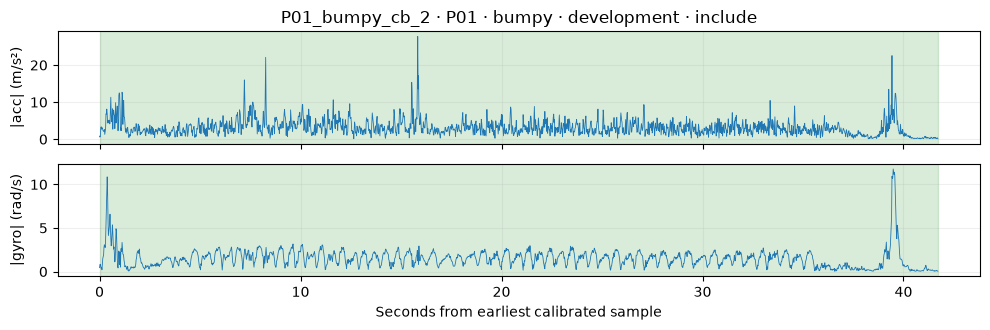

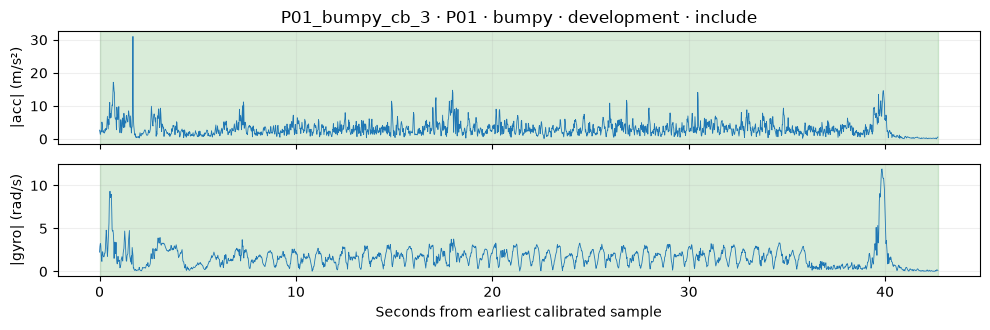

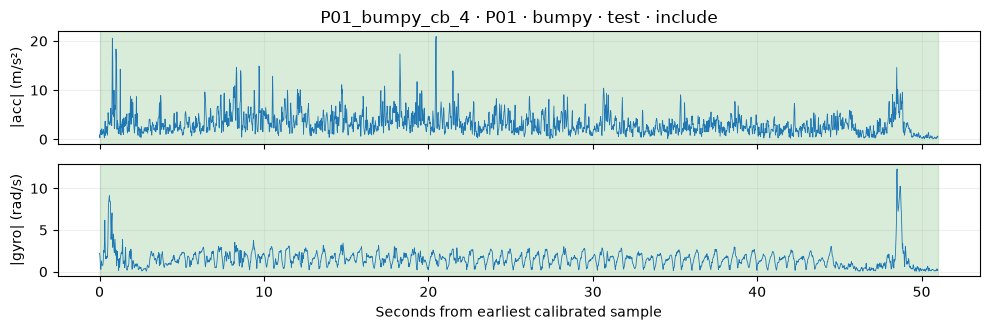

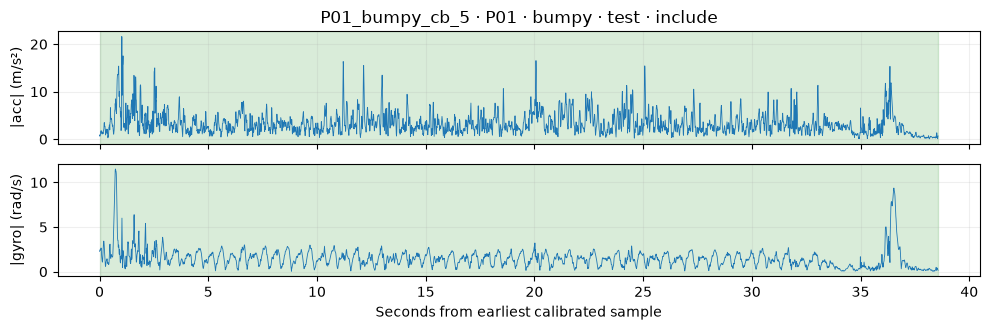

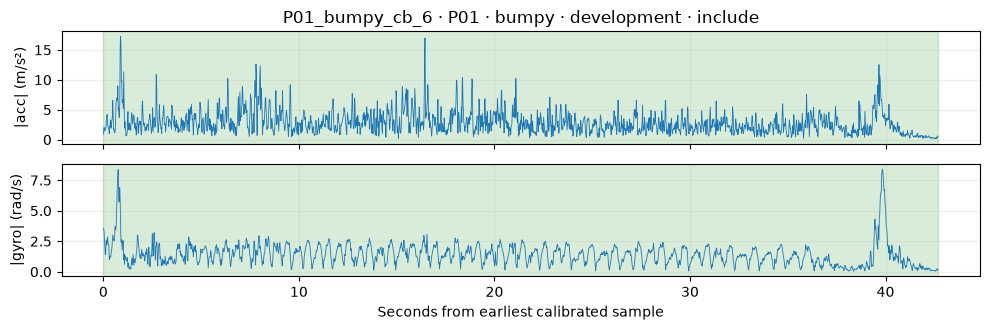

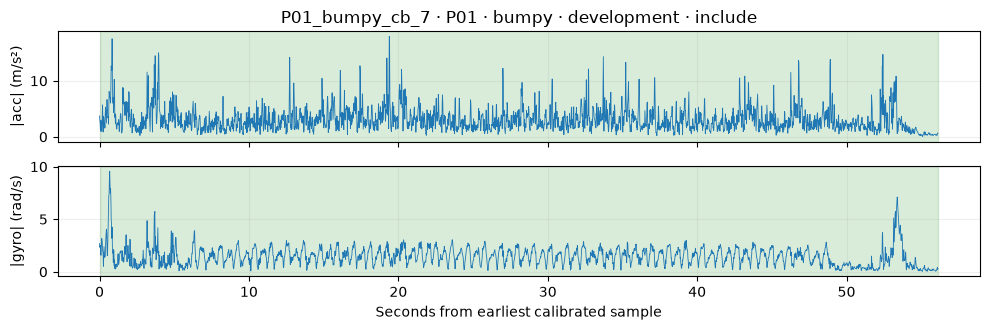

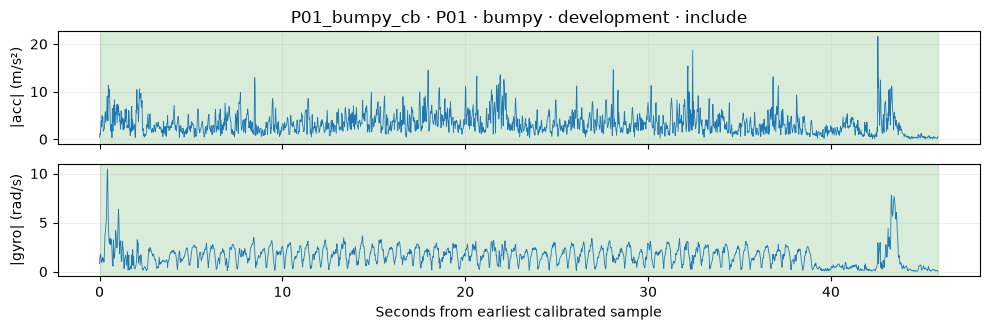

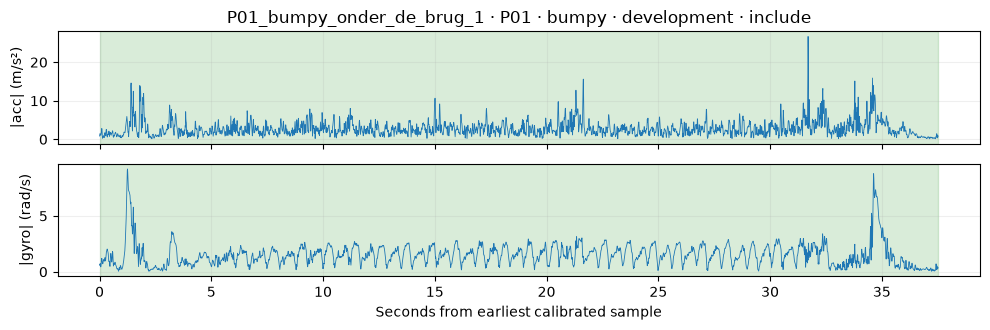

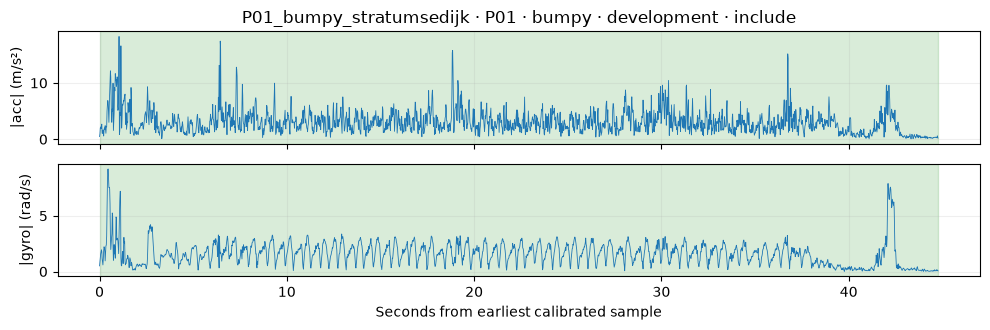

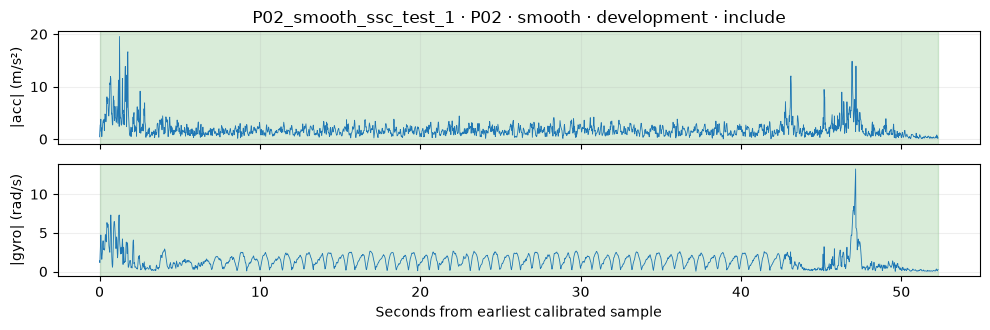

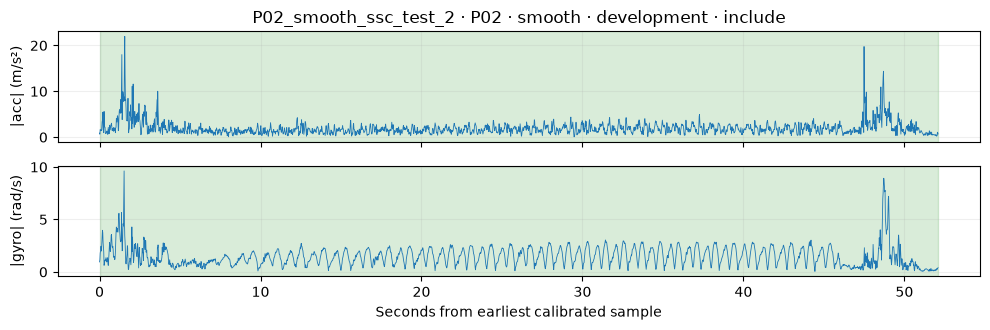

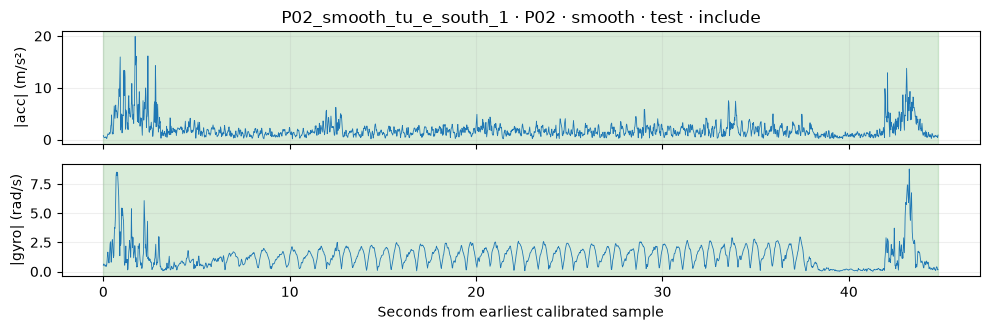

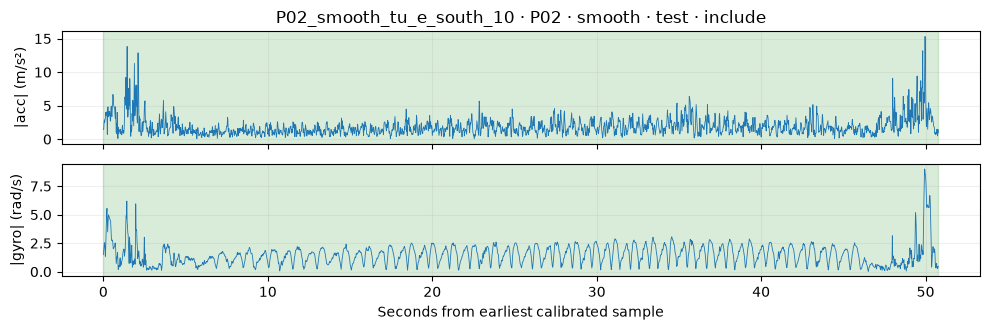

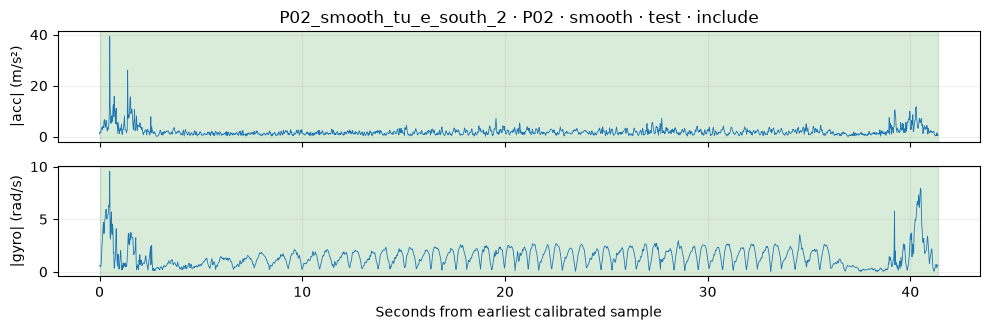

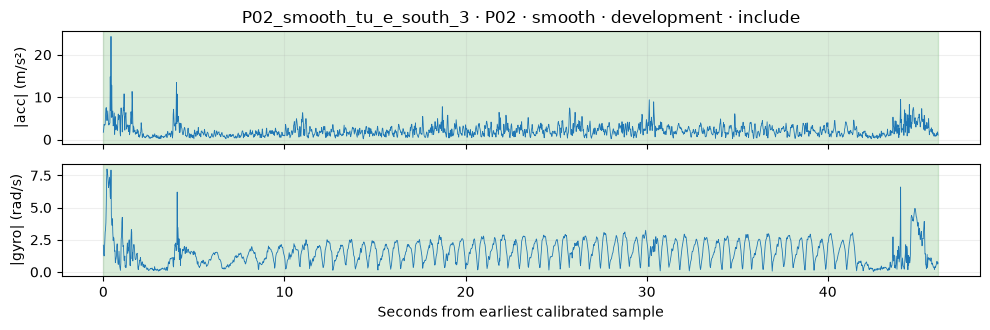

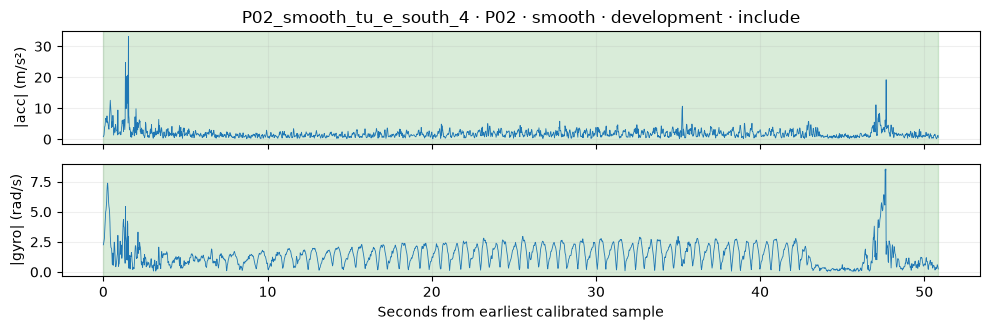

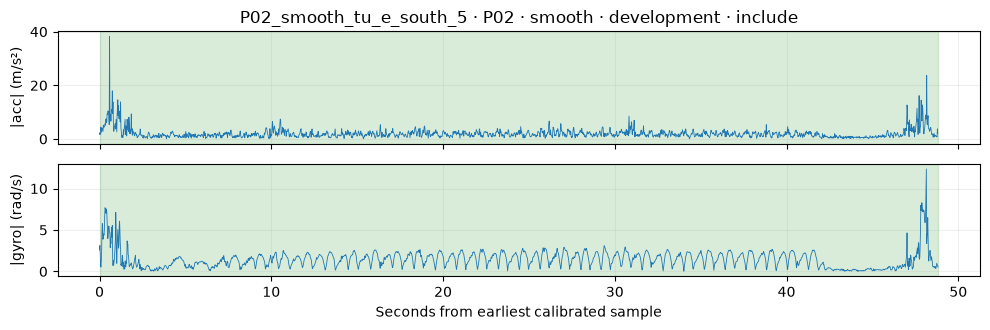

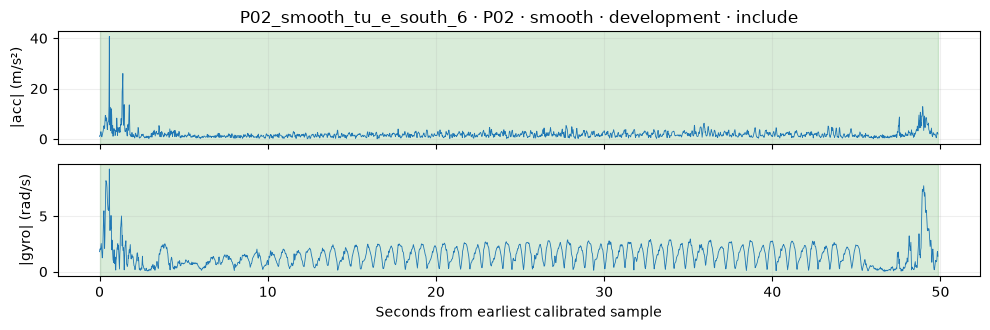

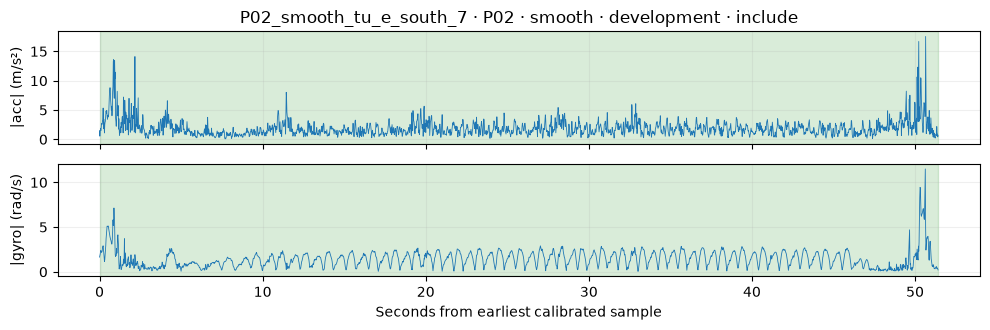

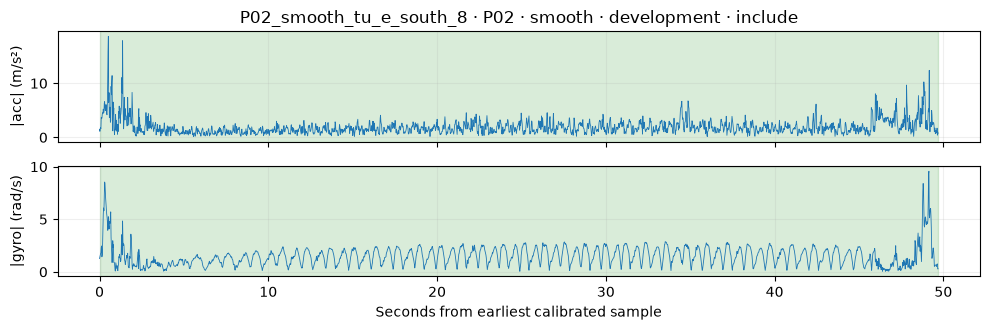

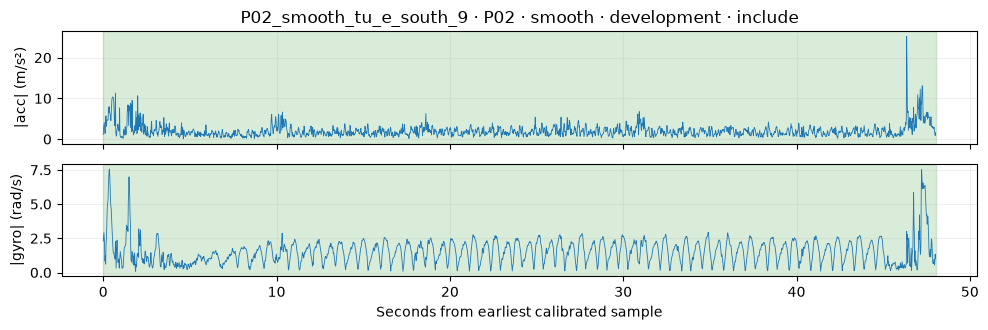

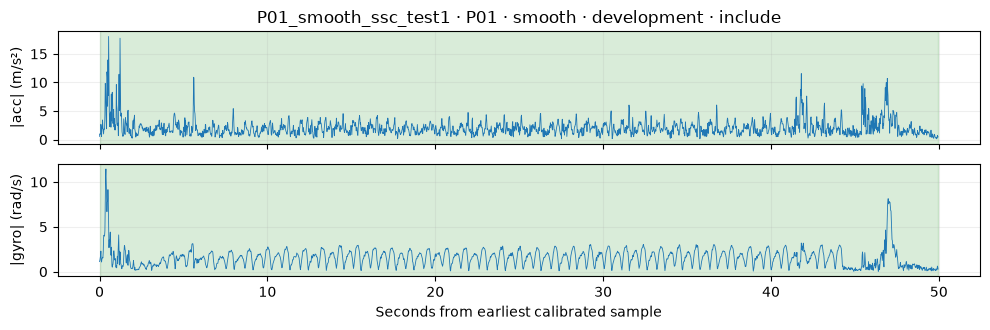

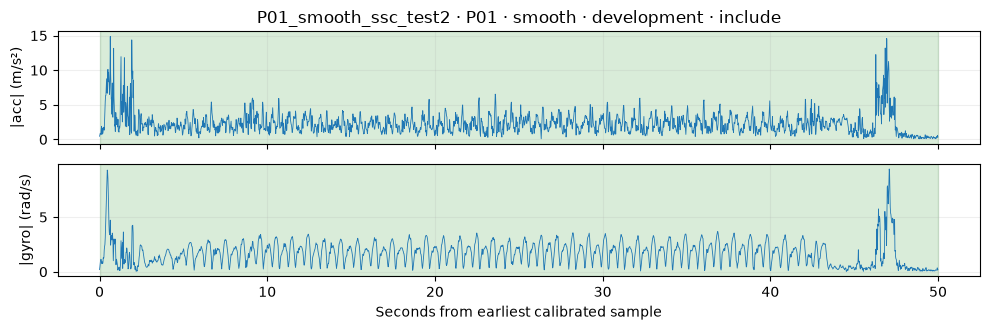

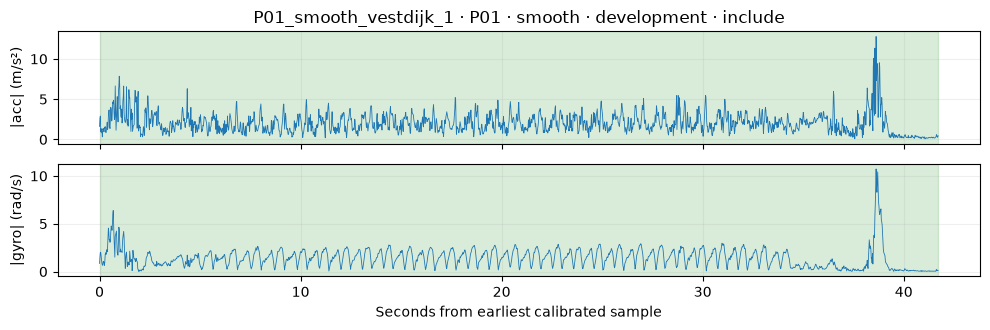

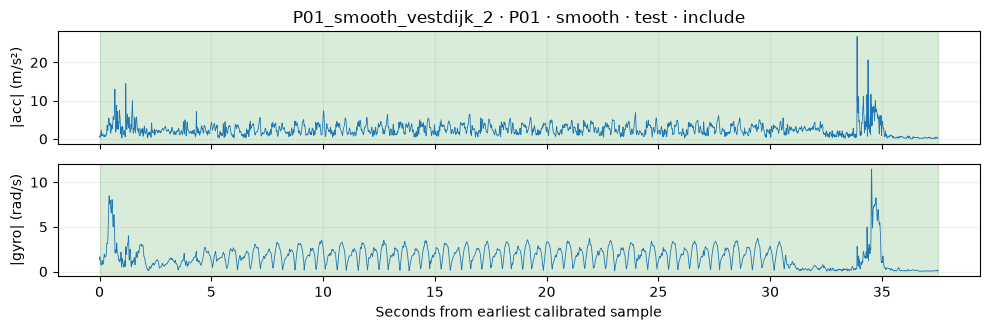

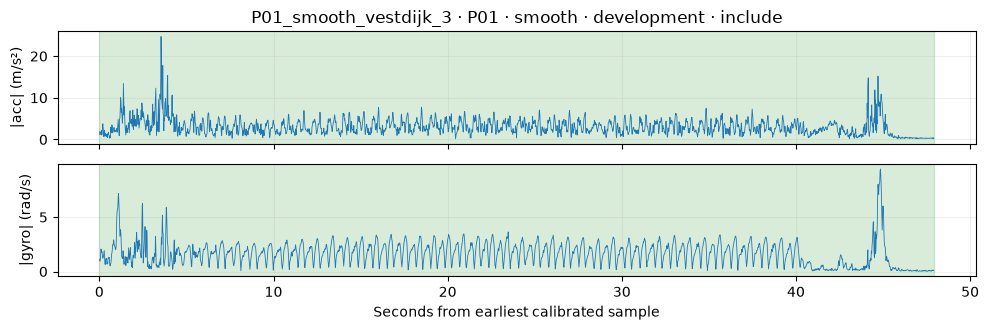

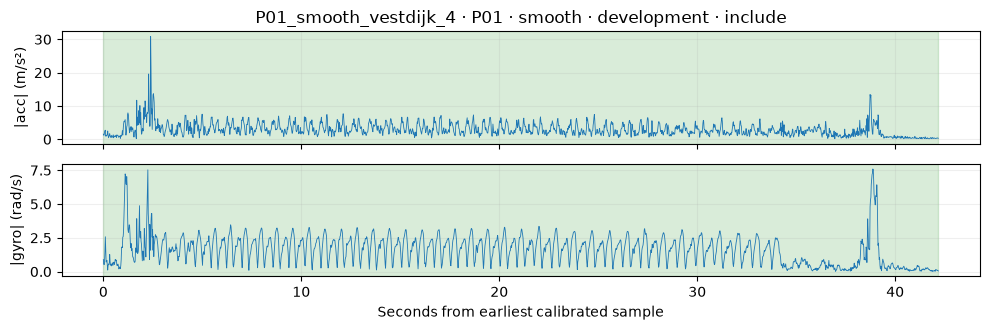

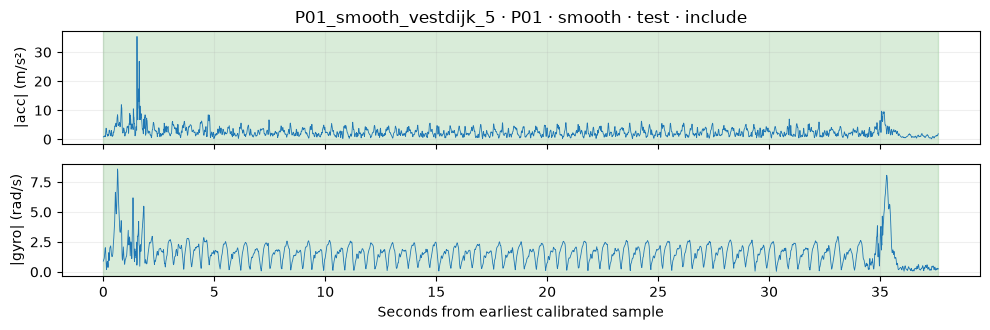

In [8]:
for recording_id, record in manifest.loc[manifest.quality_ok].iterrows():
    fig, axes = plt.subplots(2, 1, figsize=(10, 3.4), sharex=True)
    for ax, sensor, unit in zip(axes, ["Accelerometer", "Gyroscope"], ["m/s²", "rad/s"]):
        frame = streams[(recording_id, sensor)]
        times = (frame.time.to_numpy(dtype=np.int64) - origins[recording_id]) / 1e9
        magnitude = np.linalg.norm(frame[AXES].to_numpy(), axis=1)
        step = max(1, len(frame) // 2000)
        ax.plot(times[::step], magnitude[::step], linewidth=0.6)
        ax.set_ylabel(f"|{SENSORS[sensor]}| ({unit})")
        if record.review_status == "include":
            ax.axvspan(record.usable_start_s, record.usable_end_s, color="green", alpha=0.15)
    axes[0].set_title(f"{recording_id} · {record.participant_id} · {record.surface} · {record.split} · {record.review_status}")
    axes[-1].set_xlabel("Seconds from earliest calibrated sample")
    fig.tight_layout()
    plt.show()

## 6. Align the signals
We use linear interpolation to place the three sensors on the same time grid. Samples inside long
gaps are marked invalid, and any window containing them is rejected. Interpolation across a short
gap is an approximation; it does not recover the original missing measurements.

We keep acceleration and gyroscope axes and calculate their magnitudes. We also project acceleration
onto the gravity direction to obtain a feature signal that is less dependent on phone orientation.
This projection is included in the initial feature set. Its sign follows the gravity vector, while
its RMS and spread do not depend on that sign. A near-zero gravity vector cannot define a direction,
so we mark those samples invalid too.

No scaling parameters are learned here. Scaling will be fitted on training folds during modeling.

In [9]:
def prepare_recording(recording_id, start_s, end_s):
    """Return aligned signals and validity flags inside an explicit time interval."""
    if not np.isfinite([start_s, end_s]).all() or start_s >= end_s:
        raise ValueError("Expected a finite, increasing interval")
    record = manifest.loc[recording_id]
    if not record.quality_ok or not record.common_start_s <= start_s < end_s <= record.common_end_s:
        raise ValueError("Interval must lie within valid shared sensor coverage")
    start_tick = int(np.ceil(start_s * SAMPLE_RATE_HZ))
    stop_tick = int(np.floor(end_s * SAMPLE_RATE_HZ))
    grid = np.arange(start_tick, stop_tick) / SAMPLE_RATE_HZ
    valid = np.ones(len(grid), dtype=bool)
    prepared = {"time_s": grid}
    for sensor, prefix in SENSORS.items():
        frame = streams[(recording_id, sensor)]
        times = (frame.time.to_numpy(dtype=np.int64) - origins[recording_id]) / 1e9
        valid &= (grid >= times[0]) & (grid <= times[-1])
        right = np.searchsorted(times, grid, side="left")
        clipped = np.clip(right, 1, len(times) - 1)
        exact = np.isclose(grid, times[np.clip(right, 0, len(times) - 1)], rtol=0, atol=1e-9)
        valid &= exact | ((times[clipped] - times[clipped - 1]) <= MAX_GAP_SECONDS)
        for axis in AXES:
            prepared[f"{prefix}_{axis}"] = np.interp(grid, times, frame[axis])
    signals = pd.DataFrame(prepared)
    for prefix in ["acc", "gyro"]:
        signals[f"{prefix}_magnitude"] = np.linalg.norm(signals[[f"{prefix}_{a}" for a in AXES]], axis=1)
    gravity = signals[[f"gravity_{a}" for a in AXES]].to_numpy()
    gravity_norm = np.linalg.norm(gravity, axis=1)
    valid &= gravity_norm > 1e-6
    direction = gravity / np.maximum(gravity_norm[:, None], 1e-6)
    signals["acc_along_gravity"] = np.sum(signals[[f"acc_{a}" for a in AXES]].to_numpy() * direction, axis=1)
    signals["valid"] = valid
    return signals

## 7. Create windows and extract features
Each two-second window contains 200 samples on the common grid. Windows do not overlap or cross
recording boundaries. We reject windows with invalid samples and discard any incomplete final window.
The audit table records these losses.

For each of nine signals, we calculate the mean, population standard deviation, RMS, peak-to-peak
range, and interquartile range. This gives 45 candidate features. We use these as a simple baseline;
we have not yet established which features are most useful.

Window times, recording IDs, participants, and labels are kept separately from the feature columns.
They let us trace each row back to its source without giving the model information about its label.

In [10]:
SIGNAL_COLUMNS = [f"{prefix}_{axis}" for prefix in ["acc", "gyro"] for axis in AXES] + [
    "acc_magnitude", "gyro_magnitude", "acc_along_gravity"]
STATISTICS = ["mean", "std", "rms", "range", "iqr"]
FEATURE_COLUMNS = [f"{signal}_{stat}" for signal in SIGNAL_COLUMNS for stat in STATISTICS]
META_COLUMNS = ["window_id", "recording_id", "road_group", "participant_id", "surface", "split", "start_s", "end_s"]

def extract_windows(signals, record):
    """Return complete valid windows plus an audit of gaps and incomplete tails."""
    size = int(round(WINDOW_SECONDS * SAMPLE_RATE_HZ))
    assert np.isclose(size, WINDOW_SECONDS * SAMPLE_RATE_HZ)
    output, rejected = [], 0
    for offset in range(0, len(signals) - size + 1, size):
        window = signals.iloc[offset:offset + size]
        if not window.valid.all():
            rejected += 1
            continue
        row = {"window_id": f"{record.recording_id}_{offset // size:04d}",
               "recording_id": record.recording_id, "road_group": record.road_group,
               "participant_id": record.participant_id, "surface": record.surface, "split": record.split,
               "start_s": float(window.time_s.iloc[0]),
               "end_s": float(window.time_s.iloc[-1] + 1 / SAMPLE_RATE_HZ)}
        for signal in SIGNAL_COLUMNS:
            values = window[signal].to_numpy()
            statistics = [values.mean(), values.std(ddof=0), np.sqrt(np.mean(values ** 2)),
                          np.ptp(values), np.quantile(values, 0.75) - np.quantile(values, 0.25)]
            row.update({f"{signal}_{stat}": value for stat, value in zip(STATISTICS, statistics)})
        output.append(row)
    audit = {"recording_id": record.recording_id, "windows_retained": len(output),
             "windows_rejected_invalid": rejected, "tail_samples_discarded": len(signals) % size}
    return output, audit

### 7.1 Check the feature calculation on one recording
We first process one development recording to check that alignment and feature extraction work.
This preview uses the full shared interval, including possible phone handling. Its features are for
inspection only and are not added to the feature table directly; the next section processes each included recording once.

In [11]:
preview_candidates = manifest.loc[manifest.quality_ok & manifest.split.eq("development")]
if not preview_candidates.empty:
    preview_record = preview_candidates.iloc[0]
    preview_signals = prepare_recording(preview_record.recording_id,
        preview_record.common_start_s, preview_record.common_end_s)
    preview_rows, preview_audit = extract_windows(preview_signals, preview_record)
    preview_features = pd.DataFrame(preview_rows, columns=META_COLUMNS + FEATURE_COLUMNS)
    print("DIAGNOSTIC ONLY — untrimmed development recording:", preview_record.recording_id)
    display(preview_features[["window_id", "acc_magnitude_std", "gyro_magnitude_rms"]].head())
    display(pd.DataFrame([preview_audit]))

DIAGNOSTIC ONLY — untrimmed development recording: P01_bumpy_cb_2


,window_id,acc_magnitude_std,gyro_magnitude_rms
0,P01_bumpy_cb_2_0000,2.962114,3.076244
1,P01_bumpy_cb_2_0001,0.834886,1.056263
2,P01_bumpy_cb_2_0002,1.283194,1.751616
3,P01_bumpy_cb_2_0003,2.444260,1.937739
4,P01_bumpy_cb_2_0004,2.607084,1.935510


,recording_id,windows_retained,windows_rejected_invalid,tail_samples_discarded
0,P01_bumpy_cb_2,20,0,172


### 7.2 Process the selected intervals
We process all included recordings using their selected start and end times. By default, these span
the full shared sensor interval. Optional trims or exclusions from section 5 are applied here.
The inventory records the reason for each decision, and the audit shows retained and rejected windows.

In [12]:
feature_rows, window_audits = [], []
for _, record in manifest.loc[manifest.review_status.eq("include")].iterrows():
    signals = prepare_recording(record.recording_id, record.usable_start_s, record.usable_end_s)
    rows, audit = extract_windows(signals, record)
    feature_rows.extend(rows)
    window_audits.append(audit)
features = pd.DataFrame(feature_rows, columns=META_COLUMNS + FEATURE_COLUMNS)
window_audit = pd.DataFrame(window_audits, columns=["recording_id", "windows_retained", "windows_rejected_invalid", "tail_samples_discarded"])
print(f"Included windows: {len(features)}; candidate features: {len(FEATURE_COLUMNS)}")
display(window_audit)
if not features.empty:
    display(pd.crosstab([features.split, features.participant_id], features.surface))
    display(features.groupby("recording_id").size().describe().to_frame("windows per recording"))

Included windows: 633; candidate features: 45


,recording_id,windows_retained,windows_rejected_invalid,tail_samples_discarded
0,P01_bumpy_cb_2,20,0,172
1,P01_bumpy_cb_3,21,0,69
2,P01_bumpy_cb_4,25,0,100
3,P01_bumpy_cb_5,19,0,56
4,P01_bumpy_cb_6,21,0,69
5,P01_bumpy_cb_7,28,0,12
6,P01_bumpy_cb,22,0,186
7,P01_bumpy_onder_de_brug_1,18,0,151
8,P01_bumpy_stratumsedijk,22,0,77
9,P02_smooth_ssc_test_1,26,0,29


surface                     bumpy  smooth
split       participant_id               
development P01               152     113
            P02                 0     221
test        P01                44      36
            P02                 0      67

,windows per recording
count,28.000000
mean,22.607143
std,2.698961
min,18.000000
25%,20.750000
50%,23.000000
75%,25.000000
max,28.000000


## 8. Prepare the inputs for modeling
Once the checks pass, `X_development` and `X_test` contain the unscaled features. Their labels and
recording groups are stored separately. Both sets must contain both classes, every included recording
must contribute windows, and any failed source checks must be resolved or explicitly excluded.

`make_preprocessor()` creates a new, unfitted pipeline that removes constant features and standardizes
the remaining features. When adding a classifier, we will fit the complete pipeline separately within
each training fold. This prevents validation data from affecting scaling or feature selection.
Removing constant features is only an initial step; we still need to compare methods for selecting
features that help distinguish the classes.

For unsupervised models, we fit without surface labels. We can use labels to evaluate clusters, but
any mapping from cluster numbers to surface classes must come from development data. Using labels
to select features would also make that preprocessing stage supervised, which needs to be stated
when comparing the approaches.

In [13]:
def make_preprocessor():
    """Create unfitted steps; append a course-approved estimator for fold-safe modeling."""
    return Pipeline([("remove_constants", VarianceThreshold()), ("scale", StandardScaler())])

blockers = []
if manifest.review_status.eq("blocked").any():
    blockers.append(f"{int(manifest.review_status.eq('blocked').sum())} recordings have unresolved quality failures")
if (manifest.review_status.eq("include") & ~manifest.quality_ok).any():
    blockers.append("Included recordings have source-quality failures")
if not window_audit.empty and window_audit.windows_retained.eq(0).any():
    blockers.append("At least one included recording produced no valid windows")
for split in ["development", "test"]:
    if set(features.loc[features.split.eq(split), "surface"]) != set(LABEL_MAP):
        blockers.append(f"{split} lacks valid windows from both classes")
if features.split.eq("unassigned").any():
    blockers.append("Included recordings have no split assignment")

modeling_ready = not blockers
X_development = X_test = y_development = y_test = development_groups = None
cv_splits = []
development = held_out = None
if modeling_ready:
    development = features.loc[features.split.eq("development")].reset_index(drop=True)
    held_out = features.loc[features.split.eq("test")].reset_index(drop=True)
    X_development = development[FEATURE_COLUMNS].astype(float)
    X_test = held_out[FEATURE_COLUMNS].astype(float)
    y_development = development.surface.map(LABEL_MAP).astype(int)
    y_test = held_out.surface.map(LABEL_MAP).astype(int)
    development_groups = development.road_group
    group_counts = development.drop_duplicates("road_group").surface.value_counts()
    folds = min(3, int(group_counts.min()))
    if folds >= 2:
        cv = StratifiedGroupKFold(n_splits=folds, shuffle=True, random_state=SEED)
        for train_idx, validation_idx in cv.split(X_development, y_development, development_groups):
            assert set(development_groups.iloc[train_idx]).isdisjoint(development_groups.iloc[validation_idx])
            if y_development.iloc[train_idx].nunique() != 2 or y_development.iloc[validation_idx].nunique() != 2:
                blockers.append("Grouped validation fold lacks a class; revise development grouping/split")
                break
            cv_splits.append((train_idx, validation_idx))
    else:
        blockers.append("Too few independent development roads per class for cross-validation")
    if blockers:
        modeling_ready = False
        X_development = X_test = y_development = y_test = development_groups = None
        cv_splits = []
print("READY FOR MODELING" if modeling_ready else "NOT READY FOR MODELING")
for reason in blockers:
    print("-", reason)

READY FOR MODELING


## 9. Check the prepared dataset
We check that features are finite, window IDs are unique, window durations are correct, and road
groups do not cross splits. These checks catch processing mistakes but do not establish model quality.

Long recordings contribute more windows, so we will report recording-level results alongside
window-level metrics. Brian's missing bumpy recordings remain a limitation even if all processing
checks pass.

In [14]:
assert len(FEATURE_COLUMNS) == 45 and len(set(FEATURE_COLUMNS)) == 45
assert not set(FEATURE_COLUMNS).intersection(META_COLUMNS)
assert features.window_id.is_unique
if not features.empty:
    assert np.isfinite(features[FEATURE_COLUMNS].to_numpy(dtype=float)).all()
    assert np.allclose(features.end_s - features.start_s, WINDOW_SECONDS)
    assert features.groupby("recording_id").split.nunique().max() == 1
    assert features.groupby("road_group").split.nunique().max() == 1
    assert features.recording_id.isin(manifest.index[manifest.review_status.eq("include")]).all()
if modeling_ready:
    assert list(X_development.columns) == list(X_test.columns) == FEATURE_COLUMNS
    assert set(development.road_group).isdisjoint(held_out.road_group)
    print(f"Handoff verified: {len(X_development)} development windows, {len(X_test)} test windows, {len(cv_splits)} folds.")
else:
    print("Structural checks passed; modeling handoff remains blocked by the reasons above.")
print("Raw sensor files were read only. External deployment data was not loaded.")

Handoff verified: 486 development windows, 147 test windows, 3 folds.
Raw sensor files were read only. External deployment data was not loaded.


## 10. Remaining assignment work
The preparation code is in place. Our next steps are to:

1. Add any further recordings and freeze the data split before tuning. Trimming is an optional
   development-data comparison; the baseline retains recording starts and ends.
2. Complete the group details and anonymize the submitted sensor data and metadata.
3. Explore development features and compare window settings and feature-selection methods within
   cross-validation.
4. Train four supervised and four unsupervised models from the course. Compare them using consistent
   data splits, suitable metrics, confusion matrices, feature-selection plots, and recording-level errors.
5. Select a model using development results, evaluate it on the reserved test set, and then apply the
   fixed pipeline to `DeploymentData`. Plot predicted road quality over time, showing invalid intervals
   as unknown. The external dataset must not be used for training, tuning, or testing.
6. Complete the CRISP-DM report (up to eight pages), `README.md`, and organized `data/` folder. Submit
   the executed notebook with the other required files using the assignment's ZIP naming instructions.

All intermediate tables are rebuilt from the source CSVs, and review decisions are stored in this
notebook. If we export processed data later, we will store it separately from the raw data and include
the settings, source hashes, review decisions, and split fingerprint needed to reproduce it.